In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

Chargement des données

In [2]:
dirpath = Path("/kaggle/input/datasets/bonaventuredanfi/datatour2026-dataset")
train = pd.read_csv(dirpath / "train.csv")
test = pd.read_csv(dirpath / "test.csv")

In [3]:
# Informations de base concernant le jeu de données
# Nous allons supprimmer la variable id, qui n'influence pas au niveau de l'entrainement car étant unique et propre à chaque utilisateur
train.drop(columns='id',inplace=True)
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1290081 entries, 0 to 1290080
Data columns (total 10 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   period                      1290081 non-null  int64  
 1   operation                   1290081 non-null  object 
 2   amount                      1290081 non-null  float64
 3   origin_account              1290081 non-null  object 
 4   origin_balance_before       1290081 non-null  float64
 5   origin_balance_after        1290081 non-null  float64
 6   destination_account         1290081 non-null  object 
 7   destination_balance_before  1290081 non-null  float64
 8   destination_balance_after   1290081 non-null  float64
 9   fraud_flag                  1290081 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 98.4+ MB


In [4]:
# Apercu des dix premières lignes du dataset d'entrainement
train.head(10)

,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
0,0,op_05,636.75,acc_o_307358626ad66fed,87.00,-549.75,acc_d_7fac3b16af7d127b,630.88,1267.62,0
1,0,op_05,636.12,acc_o_aeb690c57bf5d1de,76.93,76.93,acc_d_1d6120e8b117aa14,731.70,731.70,0
2,0,op_05,681.00,acc_o_655c41913944d2b7,15943.74,15262.75,acc_d_ec2c21517a0ccb1a,758.83,1439.84,0
3,0,op_03,28175.40,acc_o_ba23a2b955a79a8b,-443.88,-28619.28,acc_d_a3dd8504815ec133,770924.84,799100.24,0
4,0,op_03,86429.15,acc_o_d05a23079bd066c1,-670.85,-87100.01,acc_d_0d4880267e62d5c4,91.13,86520.29,0
5,0,op_05,787.04,acc_o_6d8f4254f3f09623,25.81,25.81,acc_d_d2528fd81d284bd6,0.00,0.00,0
6,0,op_05,771.06,acc_o_6ad1fd4988e085ad,572637.44,571866.37,acc_d_256141e7a7c7947e,629.98,1401.04,0
7,0,op_05,758.83,acc_o_ed558e2b5b5af5f7,115.21,-643.62,acc_d_89927ea80de472e6,0.00,758.83,0
8,0,op_03,96800.66,acc_o_9cc0fd44ac3f05d3,-658.41,-97459.06,acc_d_a0682983bf40c207,70.76,96871.41,1
9,0,op_05,649.32,acc_o_d185654afcfec4e4,93.32,93.32,acc_d_4a34c3d6fd957589,706.31,706.31,0


In [5]:
# Nous allons aussi supprimer les addresses, des comptes sources et de destinations *
train.drop(columns=['origin_account','destination_account'],inplace=True)

In [6]:
train["fraud_flag"].value_counts()

fraud_flag
0    1160539
1     129542
Name: count, dtype: int64

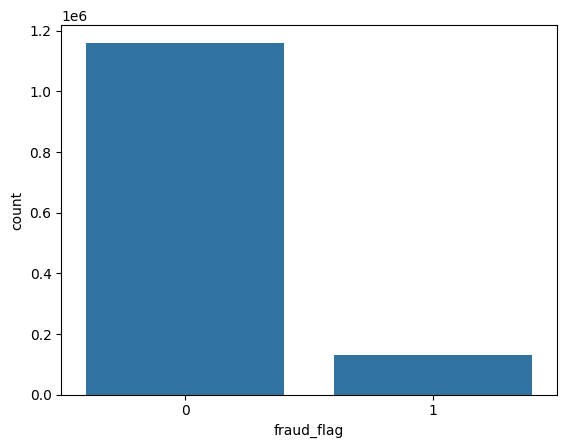

In [7]:
sns.countplot(data=train, x="fraud_flag")
plt.show()

*On remarque un large déséquilibre en le nombre de transactions non frauduleuse et celles frauduleuses*

Il s'avère nécessaire d'utiliser une technique de reéchantillonage afin d'éviter les biais dans le model à construire